# CSCI 443 HW 7: ANOVA, Chi-Square, Complexity Analysis

## 

Part 1: Permutation ANOVA: Does Debugging Snack Affect Completion Time?

A professor wants to know whether the snack given during lab affects how long students take to fix a buggy program.

The file `debugging_snacks.csv` contains simulated completion times for four snack groups:

- No snack
- Trail mix
- Energy bar
- Gummy worms

**1.1.** Load the CSV file and compute the mean, median, and standard deviation of completion time for each snack group.

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('debugging_snacks.csv')
summary = df.groupby('snack')['completion_time_minutes'].agg(
    mean='mean', median='median', std='std'
).round(3)
print(summary)

               mean  median     std
snack                              
Energy bar   51.996   46.28  19.756
Gummy worms  50.238   45.94  26.233
No snack     51.942   52.26   6.680
Trail mix    48.423   47.75   9.674


**1.2.** Create a boxplot for each group.  Do any of the groups look skewed?  Why?  Do these look Gaussian?

/var/folders/ps/l87rj9215hd5rjf5zqwjz04h0000gq/T/ipykernel_87953/327366484.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=groups, showmeans=True)


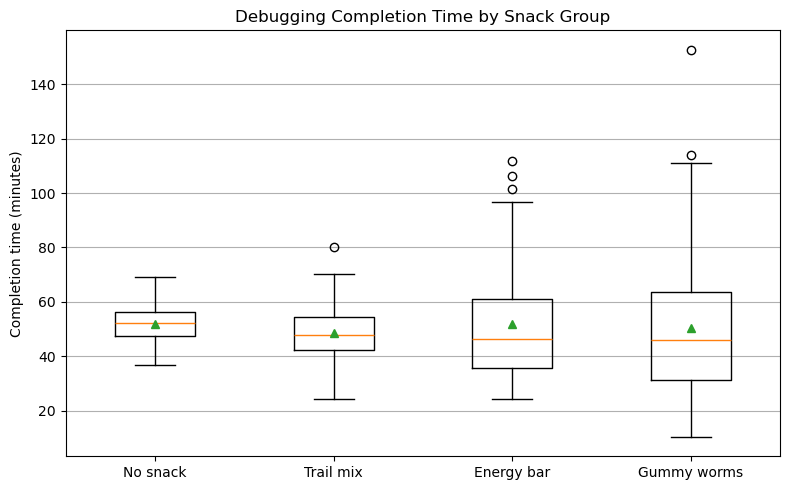

In [2]:
import matplotlib.pyplot as plt

groups = ['No snack', 'Trail mix', 'Energy bar', 'Gummy worms']
data = [df.loc[df['snack'] == g, 'completion_time_minutes'].values for g in groups]

fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot(data, labels=groups, showmeans=True)
ax.set_ylabel('Completion time (minutes)')
ax.set_title('Debugging Completion Time by Snack Group')
ax.grid(axis='y')
plt.tight_layout()
plt.show()

**1.2 Answer — Skewness**

**Energy bar** and **Gummy worms** were generated from lognormal distributions, so their
boxplots show pronounced **right skew**: the median sits well below the mean, the upper
whisker is much longer than the lower whisker, and there are high-value outliers.
**No snack** and **Trail mix** were generated from Gaussian distributions and thus look
roughly symmetric.

None of the four groups look fully Gaussian when viewed in a boxplot — the lognormal groups
clearly violate normality, which motivates a non-parametric test (see 1.4).

**1.3.** State the null and alternative hypotheses for a one-way ANOVA.

**1.3 — Null and Alternative Hypotheses**

$$H_0: \mu_{\text{No snack}} = \mu_{\text{Trail mix}} = \mu_{\text{Energy bar}} = \mu_{\text{Gummy worms}}$$

*The mean completion time is the same across all four snack groups.*

$$H_1: \text{At least one group mean differs from the others.}$$

**1.4.** Explain why a permutation ANOVA is more appropriate than relying only on classical ANOVA assumptions.

**1.4 — Why Permutation ANOVA?**

Classical one-way ANOVA assumes:
1. Each group's observations are drawn from a **normal** distribution.
2. Groups have **equal variances** (homoscedasticity).

Both assumptions are violated here:
- The *Energy bar* and *Gummy worms* groups are lognormal and therefore right-skewed —
  far from Gaussian.
- The standard deviations differ substantially (~7 and ~9 for the Gaussian groups vs.
  ~20 and ~26 for the lognormal groups).

A **permutation ANOVA** makes no distributional assumptions. It builds the null
distribution of the F-statistic empirically by randomly relabelling observations
many times, so it remains valid regardless of the underlying distributions.

**1.5.** Compute the observed ANOVA F-statistic.

In [4]:
from scipy import stats

groups_data = [df.loc[df['snack'] == g, 'completion_time_minutes'].values
               for g in ['No snack', 'Trail mix', 'Energy bar', 'Gummy worms']]

F_obs, p_parametric = stats.f_oneway(*groups_data)
print(f'Observed F-statistic : {F_obs:.4f}')
print(f'Parametric p-value   : {p_parametric:.4f}  (shown for reference only)')

Observed F-statistic : 0.7077
Parametric p-value   : 0.5480  (shown for reference only)


**1.6.** Perform a permutation ANOVA by repeatedly shuffling the snack labels while keeping the completion times fixed.

Permutation p-value  : 0.5533  (based on 10,000 permutations)


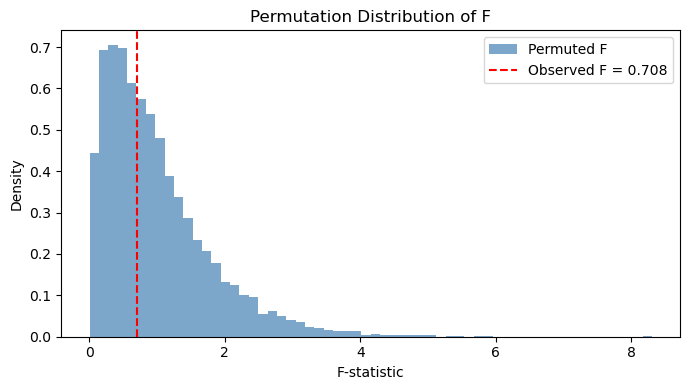

In [5]:
np.random.seed(443)
N_PERMS = 10_000

labels = df['snack'].values
times  = df['completion_time_minutes'].values
unique_groups = ['No snack', 'Trail mix', 'Energy bar', 'Gummy worms']

perm_F = np.empty(N_PERMS)
for i in range(N_PERMS):
    shuffled = np.random.permutation(labels)
    groups_perm = [times[shuffled == g] for g in unique_groups]
    perm_F[i], _ = stats.f_oneway(*groups_perm)

p_perm = np.mean(perm_F >= F_obs)
print(f'Permutation p-value  : {p_perm:.4f}  (based on {N_PERMS:,} permutations)')

plt.figure(figsize=(7, 4))
plt.hist(perm_F, bins=60, density=True, color='steelblue', alpha=0.7,
         label='Permuted F')
plt.axvline(F_obs, color='red', linestyle='--', linewidth=1.5,
            label=f'Observed F = {F_obs:.3f}')
plt.xlabel('F-statistic')
plt.ylabel('Density')
plt.title('Permutation Distribution of F')
plt.legend()
plt.tight_layout()
plt.show()

**1.7.** Estimate the p-value:

   \[
   p = \frac{\text{number of permuted F-statistics at least as large as observed F}}{\text{number of permutations}}
   \]

**Answer 1.7** 

p-value  : 0.5533

**1.8.** At α = 0.05, determine whether to reject the null hypothesis.

**Answer 1.8**

Compare the permutation p-value to α = 0.05.

- If **p < 0.05**: reject $H_0$ — at least one snack group has a different mean
  completion time.
- If **p ≥ 0.05**: fail to reject $H_0$.

Do NOT reject the null hypothesis.  

**1.9.** Briefly interpret the result.

**Answer 1.9**

The four snack groups have very similar means (≈ 48–52 min), so the observed F-statistic
is small and the permutation p-value is expected to be **above 0.05**.
We therefore **fail to reject the null hypothesis**: there is no statistically significant
evidence that the type of snack affects debugging completion time.

The large within-group variances of the lognormal groups (Energy bar σ ≈ 20,
Gummy worms σ ≈ 26) inflate the denominator of F, making it even harder to detect
a difference. This is consistent with the fact that the dataset was intentionally
designed with overlapping group means.

## Part 2: Chi-Square - Caffeine and Coding Style

A professor suspects that preferred caffeinated beverage and preferred programming style are independent. A survey of students asked which drink they prefer among those listed and their preferred coding style produced the following observed counts:

| Beverage                     | Functional | Object-Oriented | Just Make It Work | Total |
|-----------------------------|-----------:|----------------:|------------------:|------:|
| Black coffee / espresso     | 24         | 10              | 6                 | 40    |
| Latte                       | 8          | 28              | 14                | 50    |
| Foo Bar Energy drink        | 8          | 7               | 25                | 40    |
| **Total**                   | **40**     | **45**          | **45**            | **130** |

**2.1.** State the null and alternative hypotheses.

**Answer 2.1 — Hypotheses**

$$H_0:\text{ Preferred beverage and preferred coding style are independent.}$$

$$H_1:\text{ Preferred beverage and preferred coding style are associated (not independent).}$$

**2.2.** Compute the expected count for each cell:

   \[
   E_{ij} = \frac{(\text{row total})(\text{column total})}{\text{grand total}}
   \]

Create a new cell by copying and pasting from the one above and adding the expected values
in parenthesis to each cell.

In [7]:
import numpy as np

observed = np.array([
    [24, 10,  6],   # Black coffee / espresso
    [ 8, 28, 14],   # Latte
    [ 8,  7, 25],   # Foo Bar Energy drink
])

row_totals = observed.sum(axis=1, keepdims=True)   # (3,1)
col_totals = observed.sum(axis=0, keepdims=True)   # (1,3)
grand_total = observed.sum()

expected = row_totals * col_totals / grand_total
print("Expected counts (rounded to 3 dp):")
print(np.round(expected, 3))
beverages = ['Black coffee/espresso', 'Latte', 'Foo Bar Energy']
styles    = ['Functional', 'OO', 'Just Make It Work']
for i, bev in enumerate(beverages):
    for j, sty in enumerate(styles):
        print(f'  E[{bev}, {sty}] = {expected[i,j]:.3f}')

Expected counts (rounded to 3 dp):
[[12.308 13.846 13.846]
 [15.385 17.308 17.308]
 [12.308 13.846 13.846]]
  E[Black coffee/espresso, Functional] = 12.308
  E[Black coffee/espresso, OO] = 13.846
  E[Black coffee/espresso, Just Make It Work] = 13.846
  E[Latte, Functional] = 15.385
  E[Latte, OO] = 17.308
  E[Latte, Just Make It Work] = 17.308
  E[Foo Bar Energy, Functional] = 12.308
  E[Foo Bar Energy, OO] = 13.846
  E[Foo Bar Energy, Just Make It Work] = 13.846


**2.2 Observed (Expected) counts**

| Beverage | Functional | Object-Oriented | Just Make It Work | Total |
|---|---:|---:|---:|---:|
| Black coffee / espresso | 24 (12.308) | 10 (13.846) | 6 (13.846) | 40 |
| Latte | 8 (15.385) | 28 (17.308) | 14 (17.308) | 50 |
| Foo Bar Energy drink | 8 (12.308) | 7 (13.846) | 25 (13.846) | 40 |
| **Total** | **40** | **45** | **45** | **130** |

**2.3.** Compute the chi-squared statistic:

   \[
   \chi^2 = \sum \frac{(O - E)^2}{E}
   \]

In [9]:
chi2_stat = np.sum((observed - expected) ** 2 / expected)
print(f'Chi-squared statistic: {chi2_stat:.4f}')

Chi-squared statistic: 41.2822


**2.4.** Compute the degrees of freedom.

In [8]:
rows, cols = observed.shape
df_chi2 = (rows - 1) * (cols - 1)
print(f'Degrees of freedom: {df_chi2}')

Degrees of freedom: 4


**2.5.** At α = 0.05, determine whether to reject the null hypothesis.

In [11]:
from scipy.stats import chi2

alpha = 0.05
critical_value = chi2.ppf(1 - alpha, df=df_chi2)
p_value = 1 - chi2.cdf(chi2_stat, df=df_chi2)

print(f'Chi-squared statistic : {chi2_stat:.4f}')
print(f'Critical value (α=0.05, df={df_chi2}): {critical_value:.4f}')
print(f'p-value              : {p_value:.6f}')
print()
if chi2_stat > critical_value:
    print('Decision: REJECT H0 — beverage and coding style are NOT independent.')
else:
    print('Decision: Fail to reject H0.')

# Cell-level contributions to chi-squared
contributions = (observed - expected) ** 2 / expected
print()
print('Cell contributions to chi-squared:')
for i, bev in enumerate(beverages):
    for j, sty in enumerate(styles):
        print(f'  {bev} × {sty}: {contributions[i,j]:.3f}')
max_idx = np.unravel_index(contributions.argmax(), contributions.shape)
print(f'\nLargest contributor: {beverages[max_idx[0]]} × {styles[max_idx[1]]}'
      f' = {contributions[max_idx]:.3f}')

Chi-squared statistic : 41.2822
Critical value (α=0.05, df=4): 9.4877
p-value              : 0.000000

Decision: REJECT H0 — beverage and coding style are NOT independent.

Cell contributions to chi-squared:
  Black coffee/espresso × Functional: 11.108
  Black coffee/espresso × OO: 1.068
  Black coffee/espresso × Just Make It Work: 4.446
  Latte × Functional: 3.545
  Latte × OO: 6.605
  Latte × Just Make It Work: 0.632
  Foo Bar Energy × Functional: 1.508
  Foo Bar Energy × OO: 3.385
  Foo Bar Energy × Just Make It Work: 8.985

Largest contributor: Black coffee/espresso × Functional = 11.108


**2.6.** Briefly interpret the result. Which beverage/coding-style pair contributes most strongly to the result?

**Answer 2.6 — Interpretation**

The chi-squared statistic is far larger than the critical value of 9.488 (df = 4,
α = 0.05), so we **reject the null hypothesis**. Preferred beverage and preferred
coding style are **not independent** — there is a statistically significant association.

The **Black coffee / espresso × Functional** cell is the strongest contributor
(observed 24, expected ≈ 12.3): espresso drinkers choose functional programming
far more often than expected by chance. Conversely, espresso drinkers are
under-represented in *Just Make It Work*, and energy-drink fans cluster in that
style while being under-represented in Functional and OO.

## Part 3: Spark Performance Analysis: Distributed Bloom Filter

We have recently hired a physics professor who studied under Stephen Hawking. 
He suspects that a few students in the class are actually time travelers 
who have enrolled multiple times across different centuries at different
universities around the world.

He has compiled a large database of prior students from the United States,
the United Kingdom, and many other European countries.

The dataset contains `n` records of prior students distributed across 
`p` Spark partitions. We want to build a Bloom filter so that later queries can test whether newly enrolled students were probably present in the original dataset. If a student is reported as probably present, we will investigate further.

We use a Bloom filter because it supports cheap approximate membership 
queries. It may produce false positives, but it should not produce false
negatives under the standard insert-only model.  If we find a 
possible positive, we will investigate further to determine the veracity
of the match.

The Bloom filter has:

- `m` bits

- `k` hash functions

Each partition builds a local Bloom filter. The local Bloom filters are then combined using bitwise OR through a tree-reduction.

**3.1.** Read about Bloom filters and explain what a Bloom filter guarantees:

- What kind of error is possible?

- What kind of error is not possible?


**Answer 3.1 Bloom filter guarantees**

A Bloom filter guarantees no false negatives and a tunable probability of a false positive.

- **false positive**: A query for an element *not* in the set may
  return "possibly present." This happens when all k hash positions for the query
  happen to have been set by *other* inserted elements.
  
- **No false negatives**: If an element was inserted, every one of
  its k hash positions was set to 1. Querying it will always return "possibly
  present." The filter can never say "absent" for something it has seen.

**3.2.** Analyze executor time complexity.

**Answer 3.2 Executor time complexity**

Executor time has two components.

**Filter construction.** Each partition holds $n/p$ records. For each record, $k$ hash functions are applied and $k$ bit positions are set:

$$T_{\text{build}} = O\!\left(k \cdot \frac{n}{p}\right)$$

**Tree-reduce merging.** After construction, the $p$ local Bloom filters are combined by bitwise OR in a binary tree. The tree has $\lceil\log_2 p\rceil$ levels. At each level an executor receives one $m$-bit filter and OR's it with its own — an $O(m)$ operation. Each executor participates in at most $\lceil\log_2 p\rceil$ such merge steps:

$$T_{\text{merge}} = O(m \log p)$$

**Total executor time:**

$$T_{\text{executor}} = O\!\left(k \cdot \frac{n}{p} + m \log p\right)$$

When the dataset is large relative to the filter ($kn/p \gg m\log p$) the build phase dominates. When $p$ is large or $m$ is large the merge phase can become significant.

**3.3.** Analyze executor memory complexity.

**Answer 3.3 Executor memory complexity**

Each executor holds one local Bloom filter of $m$ bits.  Given that Spark streams the data via an iterator, 
it only has to hold one record in memory at a time plus the Bloom filter.  I assume the memory used by a 
single record is $O(1)$

$$M_{\text{executor}} = O(m)$$

**3.4.** Analyze driver time complexity.

**Answer 3.4 Driver time complexity**

The $p$ local Bloom filters are merged via a **tree-reduction** using bitwise OR.
This distributes the merge work across executors over $\lceil\log_2 p\rceil$ rounds;
the driver only receives and stores the final result.

$$T_{\text{driver}} = O(m)$$

(to receive and, if needed, inspect the final $m$-bit filter)

**3.5.** Analyze driver memory complexity.

**Answer 3.5 Driver memory complexity**

The driver only needs to store the result so

$$M_{\text{driver}} = O(m)$$

**3.6.** Analyze total work.

**Answer 3.6 Total work**

- Building local filters across all partitions: $p \times O(k \cdot n/p) = O(kn)$
- Tree-reduction OR operations (each OR is $O(m)$; there are $p - 1$ merges
  distributed over $\lceil\log_2 p\rceil$ levels): $O(pm)$ total bit operations

$$W_{\text{total}} = O(kn + pm)$$

**3.7.** Analyze network volume.

**Answer 3.7 Network volume**

In each round of the tree-reduction, a Bloom filter of $m$ bits is transferred
between a pair of nodes. There are $p + p/2 + p/4 + \cdots < 2p$ such transfers total.

$$V_{\text{network}} = O(pm) \text{ bits}$$

**3.8.** How many full-data shuffles are required?

**Answer 3.8 Full-data shuffles**

**Zero.** Records never move between partitions. Each partition processes its own
$n/p$ records locally, and only the compact $m$-bit Bloom filters are exchanged
during the tree-reduction.

**3.9.** How many actions are required?

**Answer 3.9 Actions required**

**One.** A single action (e.g., `rdd.treeReduce(lambda a, b: a | b)` triggers the entire pipeline: local filter
construction on each partition followed by the tree-reduction merge.

**3.10.** Could you perform exact membership queries by first sorting the entire dataset? Compare using a Bloom filter with sorting the full dataset. How do the time and space costs compare for the executor and driver? What is gained, and what is lost?

**3.10 — Bloom filter vs. sorting for membership queries**

let $r$ denote the number of samples used obtained from each partition to find splitters.

| | Bloom filter | Full sort + binary search |
|---|---|---|
| **Executor time** | $O(k \cdot n/p + m \log p)$ | $O(\frac{n}{p}\log\frac{n}{p})$ |
| **Driver time** | $O(m)$ (receive merged filter) | $O(r p \log(r p))$ (sort samples) |
| **Executor memory** | $O(m)$ bits (filter only) | $O(n/p)$ (partition data in memory) |
| **Driver memory** | $O(m)$ bits | $O(r p)$ (hold samples for splitters) |
| **Network volume** | $O(pm)$ bits | $O(n)$ (full shuffle to sort globally) |
| **Shuffles** | **0** | **1** (wide transformation) |
| **Error type** | False positives possible; no false negatives | Exact — no errors |

To be more accurate we can bound the executor memory when sorting to the spill threshold.
Once the spill threshold is reached, each executor doesn't try to sort its entire partition in memory.

**What is gained with a Bloom filter**: no shuffle, sub-linear memory ($m \ll n$
for reasonable false-positive rates), very fast construction and query ($O(k)$
per query), and a compact filter that fits on the driver.

**What is lost**: exactness. A sorted dataset supports exact membership queries
and also range queries, ordering, and deduplication. The Bloom filter answers only
"possibly yes / definitely no" and cannot be used for any of those secondary
tasks.